Sukhada Bhoyar - 23070521033

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.optimizers import Adam


In [ ]:
# -----------------------------
# Load Dataset
# -----------------------------
housing = fetch_california_housing()

X = housing.data
y = housing.target

In [ ]:
# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [ ]:
# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# -----------------------------
# Baseline Model
# -----------------------------
baseline = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

baseline.compile(
    optimizer=Adam(0.001),
    loss='mse',
    metrics=['mae']
)

history_base = baseline.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# -----------------------------
# L2 Regularization Model
# -----------------------------
l2_model = Sequential([
    Dense(64,
          activation='relu',
          kernel_regularizer=l2(0.001),
          input_shape=(X_train.shape[1],)),
    Dense(32,
          activation='relu',
          kernel_regularizer=l2(0.001)),
    Dense(1)
])

l2_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_l2 = l2_model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=0
)

In [ ]:
# -----------------------------
# Dropout Model
# -----------------------------
drop_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

drop_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_drop = drop_model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=0
)

In [ ]:
# -----------------------------
# Evaluation Function
# -----------------------------
def evaluate(model, name):
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)

    print(name)
    print("MSE :", mse)
    print("MAE :", mae)
    print()

evaluate(baseline, "Baseline Model")
evaluate(l2_model, "L2 Regularization")
evaluate(drop_model, "Dropout Model")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Baseline Model
MSE : 0.28611144410738265
MAE : 0.36571698682078096

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
L2 Regularization
MSE : 0.2878229802503972
MAE : 0.3577267365108684

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Dropout Model
MSE : 0.29818765349634224
MAE : 0.37565265383148844



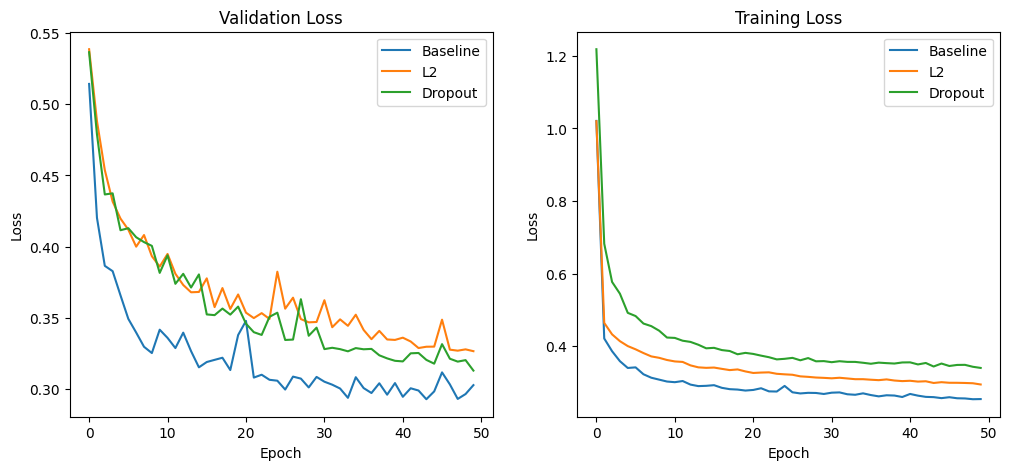

In [ ]:
# -----------------------------
# Plot Loss Curves
# -----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_base.history['val_loss'], label='Baseline')
plt.plot(history_l2.history['val_loss'], label='L2')
plt.plot(history_drop.history['val_loss'], label='Dropout')
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_base.history['loss'], label='Baseline')
plt.plot(history_l2.history['loss'], label='L2')
plt.plot(history_drop.history['loss'], label='Dropout')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()